In [1]:
# =========================================================
# LSTM FORECASTING FOR PADDY PRODUCTION
# WITH OPTUNA HYPERPARAMETER TUNING + FULL EVALUATION
# =========================================================

# ======================
# 1. IMPORT LIBRARIES
# ======================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ======================
# 2. LOAD DATA
# ======================

data = pd.read_excel(r"../df.xlsx")
df   = data.iloc[27:, :]
df   = df.sort_values("Date")
df.set_index("Date", inplace=True)
ts   = df["Avg_Yield_Total"]

print(f"Total samples : {len(ts)}")

# ======================
# 3. TRAIN / VAL / TEST SPLIT
# 70% train | 10% val | 20% test
# ======================

train_size = int(len(ts) * 0.70)
val_size   = int(len(ts) * 0.10)

train = ts.iloc[:train_size]
val   = ts.iloc[train_size : train_size + val_size]
test  = ts.iloc[train_size + val_size:]

print(f"Train : {len(train)} | Val : {len(val)} | Test : {len(test)}")

# ======================
# 4. SCALER
# ======================

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train.values.reshape(-1, 1))    # fit ONLY on train

def scale(series):
    return torch.FloatTensor(
        scaler.transform(series.values.reshape(-1, 1))
    ).view(-1)

train_scaled = scale(train)
val_scaled   = scale(val)
test_scaled  = scale(test)

# ======================
# 5. SEQUENCE CREATOR
# ======================

def create_sequences(data, seq_len):
    seqs = []
    for i in range(len(data) - seq_len):
        x = data[i : i + seq_len]
        y = data[i + seq_len].unsqueeze(0)   # shape [1] — no broadcasting warning
        seqs.append((x, y))
    return seqs

# ======================
# 6. LSTM MODEL
# ======================

class LSTMModel(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            dropout     = dropout if num_layers > 1 else 0.0,
            batch_first = False
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x           = x.view(len(x), 1, -1)
        lstm_out, _ = self.lstm(x)
        out         = self.fc(lstm_out[-1])
        return out.view(-1)              # flatten [1,1] → [1]

# ======================
# 7. TRAIN FUNCTION
# ======================

def train_lstm(train_seq, hidden_size, num_layers,
               dropout, lr, epochs):
    model     = LSTMModel(hidden_size, num_layers, dropout)
    loss_fn   = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        model.train()
        for seq, label in train_seq:
            optimizer.zero_grad()
            loss = loss_fn(model(seq), label)   # both shape [1] — no warning
            loss.backward()
            optimizer.step()
    return model

# ======================
# 8. ROLLING FORECAST FUNCTION
# ======================

def rolling_forecast(model, seed_scaled, n_steps, scaler):
    model.eval()
    preds     = []
    input_seq = seed_scaled.clone()

    with torch.no_grad():
        for _ in range(n_steps):
            y_hat = model(input_seq)                              # shape [1]
            preds.append(y_hat.item())
            input_seq = torch.cat((input_seq[1:], y_hat.detach()))  # shape consistent

    return scaler.inverse_transform(
        np.array(preds).reshape(-1, 1)
    ).reshape(-1)


C:\Users\User\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples : 67
Train : 46 | Val : 6 | Test : 15


In [2]:

# ======================
# 9. OPTUNA OBJECTIVE
# (tune on VALIDATION set only)
# ======================

def objective(trial):
    seq_len     = trial.suggest_categorical('seq_len',     [3, 5, 7])
    hidden_size = trial.suggest_categorical('hidden_size', [32, 64, 100])
    num_layers  = trial.suggest_int('num_layers', 1, 2)
    dropout     = trial.suggest_categorical('dropout',     [0.0, 0.2])
    lr          = trial.suggest_categorical('lr',          [0.001, 0.005, 0.01])
    epochs      = trial.suggest_categorical('epochs',      [80, 150])

    train_seq = create_sequences(train_scaled, seq_len)
    if len(train_seq) == 0:
        return float('inf')

    # Train 3 times, take median RMSE (handles stochasticity)
    rmses = []
    for _ in range(3):
        model = train_lstm(train_seq, hidden_size,
                           num_layers, dropout, lr, epochs)
        preds = rolling_forecast(model,
                                 train_scaled[-seq_len:],
                                 len(val), scaler)
        rmses.append(np.sqrt(mean_squared_error(val.values, preds)))

    return float(np.median(rmses))

# ======================
# 10. RUN OPTUNA
# ======================

print("\nRunning Optuna tuning (50 trials)...")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params   = study.best_params
best_val_rmse = study.best_value

print("\n===================================")
print(" OPTUNA TUNING RESULTS")
print("===================================")
print(f"Best Val RMSE : {best_val_rmse:.4f}")
print(f"Best Params   : {best_params}")



Running Optuna tuning (50 trials)...


Best trial: 10. Best value: 99.4512: 100%|██████████| 50/50 [27:41<00:00, 33.22s/it]


 OPTUNA TUNING RESULTS
Best Val RMSE : 99.4512
Best Params   : {'seq_len': 5, 'hidden_size': 100, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.01, 'epochs': 80}


In [3]:

# ======================
# 11. RETRAIN ON TRAIN+VAL
# EVALUATE ON TEST
# ======================

trainval        = ts.iloc[:train_size + val_size] 
trainval_scaled = torch.FloatTensor(
    scaler.transform(trainval.values.reshape(-1, 1))
).view(-1)

trainval_seq = create_sequences(trainval_scaled, best_params['seq_len'])

print("\nRetraining best model on Train + Val...")

# Train 3 times, pick best run
best_test_rmse = float('inf')
best_model     = None
final_preds    = None

for run in range(3):
    model = train_lstm(
        trainval_seq,
        hidden_size = best_params['hidden_size'],
        num_layers  = best_params['num_layers'],
        dropout     = best_params['dropout'],
        lr          = best_params['lr'],
        epochs      = best_params['epochs']
    )
    preds = rolling_forecast(
        model,
        trainval_scaled[-best_params['seq_len']:],
        len(test), scaler
    )
    rmse = np.sqrt(mean_squared_error(test.values, preds))
    if rmse < best_test_rmse:
        best_test_rmse = rmse
        best_model     = model
        final_preds    = preds


Retraining best model on Train + Val...


In [4]:

# ======================
# 12. MODEL EVALUATION
# ======================

y_true = test.values
y_pred = final_preds

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
r2   = r2_score(y_true, y_pred)

print("\n===================================")
print(" BEST MODEL — TEST SET EVALUATION")
print("===================================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")



 BEST MODEL — TEST SET EVALUATION
MAE  : 487.9402
RMSE : 587.1481
MAPE : 12.77%
R²   : 0.0343


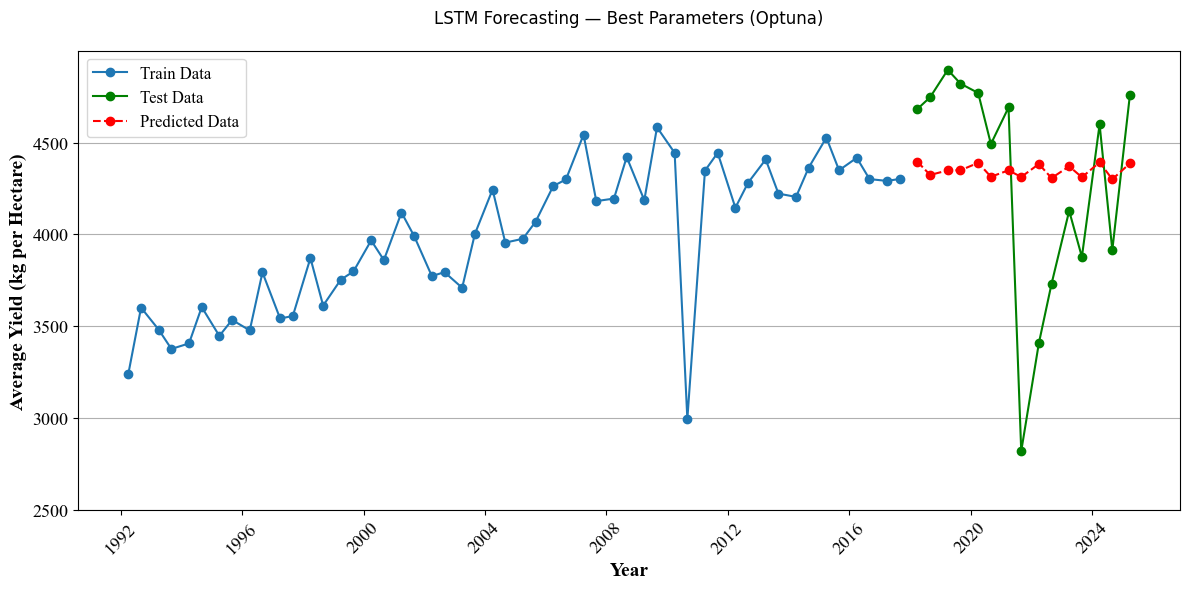

In [5]:
# ======================
# 13. ACTUAL VS PREDICTED PLOT
# ======================
train_new_size  = train_size + val_size
train = ts.iloc[:train_new_size]


plt.figure(figsize=(12, 6))

plt.plot(train.index, train.values,
         label='Train Data', marker='o', linewidth=1.5)

plt.plot(test.index, test.values,
         label='Test Data', marker='o', linewidth=1.5, color='green')

plt.plot(test.index, final_preds,
         label='Predicted Data', marker='o',
         linewidth=1.5, linestyle='--', color='red')

plt.title("LSTM Forecasting — Best Parameters (Optuna)", pad=20)
plt.xlabel("Year",                 fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)", fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.legend(prop={'size': 12, 'family': 'Times New Roman'})
plt.grid(axis='y')
plt.xticks(rotation=45, fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')
plt.ylim(2500,)
plt.tight_layout()
plt.show()


Retraining for loss curve visualization...


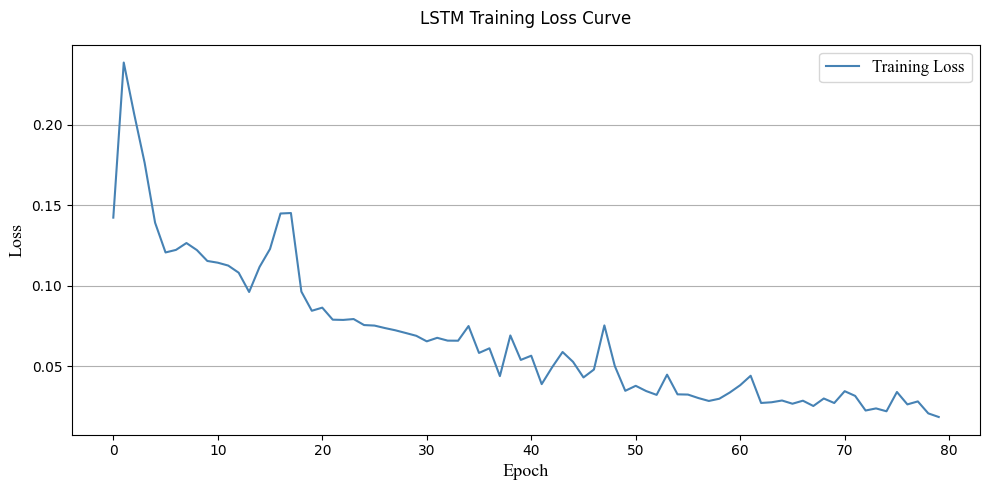

In [6]:
# ======================
# 14. LOSS CURVE (BEST MODEL RETRAIN)
# ======================

print("\nRetraining for loss curve visualization...")

model_vis   = LSTMModel(
    hidden_size = best_params['hidden_size'],
    num_layers  = best_params['num_layers'],
    dropout     = best_params['dropout']
)
loss_fn     = nn.MSELoss()
optimizer   = torch.optim.Adam(model_vis.parameters(), lr=best_params['lr'])
train_losses = []

train_seq_vis = create_sequences(train_scaled, best_params['seq_len'])

for epoch in range(best_params['epochs']):
    model_vis.train()
    epoch_loss = 0
    for seq, label in train_seq_vis:
        optimizer.zero_grad()
        loss = loss_fn(model_vis(seq), label)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_seq_vis))

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='steelblue')
plt.title("LSTM Training Loss Curve", pad=15)
plt.xlabel("Epoch",  fontsize=13, fontname='Times New Roman')
plt.ylabel("Loss",   fontsize=13, fontname='Times New Roman')
plt.legend(prop={'size': 12, 'family': 'Times New Roman'})
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [7]:
# ======================
# 15. FUTURE FORECASTING
# (Apr ↔ Sep — Yala / Maha)
# ======================

n_future  = 6
last_date = ts.index[-1]

future_dates = []
current = last_date

for _ in range(n_future):
    if current.month == 4:
        next_date = current.replace(month=9)
    else:
        next_date = current.replace(month=4, year=current.year + 1)
    future_dates.append(next_date)
    current = next_date

future_dates = pd.DatetimeIndex(future_dates)

# Retrain on FULL data for future forecast
full_scaled = torch.FloatTensor(
    scaler.fit_transform(ts.values.reshape(-1, 1))
).view(-1)

full_seq = create_sequences(full_scaled, best_params['seq_len'])

print("\nRetraining on full data for future forecast...")

future_model = train_lstm(
    full_seq,
    hidden_size = best_params['hidden_size'],
    num_layers  = best_params['num_layers'],
    dropout     = best_params['dropout'],
    lr          = best_params['lr'],
    epochs      = best_params['epochs']
)

future_preds = rolling_forecast(
    future_model,
    full_scaled[-best_params['seq_len']:],
    n_future,
    scaler
).round(2)



Retraining on full data for future forecast...


In [8]:
# ======================
# 16. FORECAST DATAFRAME
# ======================

future_df = pd.DataFrame({'Prediction': future_preds}, index=future_dates)

future_df['Season'] = np.where(future_dates.month == 4, 'Yala', 'Maha')

future_df['Year'] = np.where(
    future_dates.month == 4,
    future_dates.year,
    future_dates.year + 1
)

future_df = future_df[['Year', 'Season', 'Prediction']]

print("\n3-Year Future Forecast:")
print(future_df.to_string())


3-Year Future Forecast:
            Year Season  Prediction
2025-09-01  2026   Maha     4349.58
2026-04-01  2026   Yala     4334.11
2026-09-01  2027   Maha     4362.94
2027-04-01  2027   Yala     4367.98
2027-09-01  2028   Maha     4374.62
2028-04-01  2028   Yala     4375.29


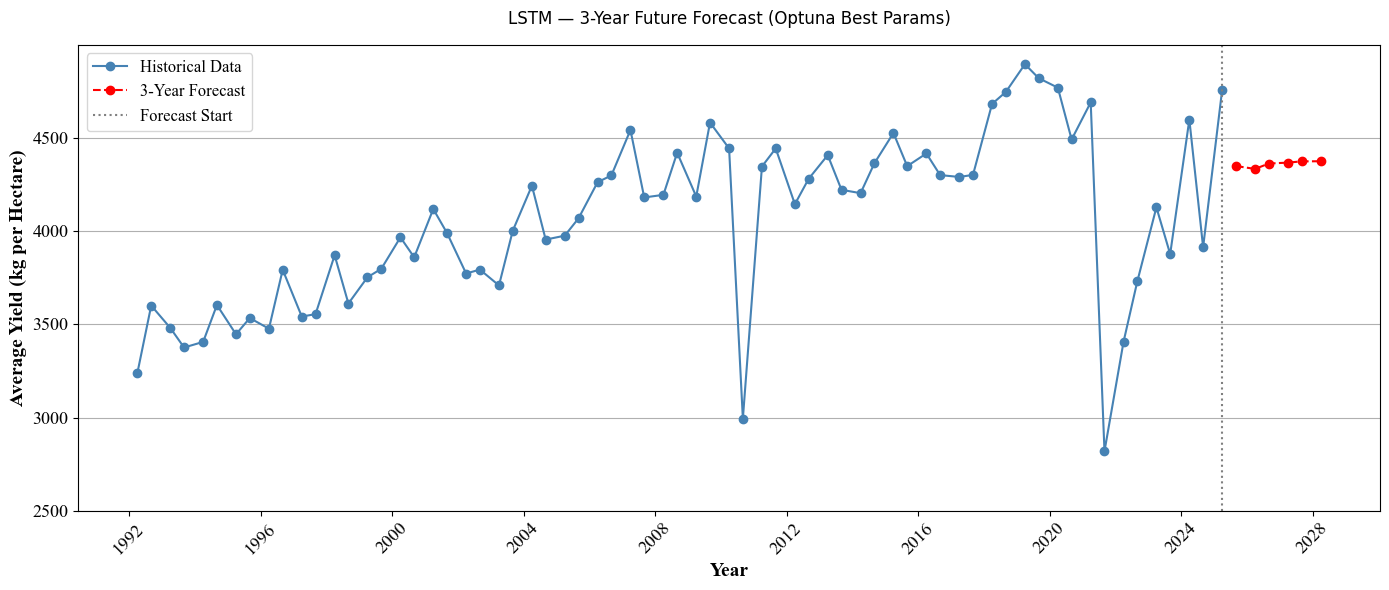

In [9]:
# ======================
# 17. PLOT FUTURE FORECAST
# ======================

plt.figure(figsize=(14, 6))

plt.plot(ts.index, ts.values,
         label='Historical Data', marker='o', linewidth=1.5, color='steelblue')

plt.plot(future_dates, future_preds,
         label='3-Year Forecast', marker='o',
         linewidth=1.5, linestyle='--', color='red')

plt.axvline(x=last_date, color='gray', linestyle=':',
            linewidth=1.5, label='Forecast Start')

plt.xlabel("Year",                 fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.ylabel("Average Yield (kg per Hectare)", fontsize=14, fontweight='bold', fontname='Times New Roman')
plt.title("LSTM — 3-Year Future Forecast (Optuna Best Params)", pad=15)
plt.legend(prop={'size': 12, 'family': 'Times New Roman'})
plt.grid(axis='y')
plt.xticks(rotation=45, fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')
plt.ylim(2500,)
plt.tight_layout()
plt.show()